# Exploratory Data Analysis – Retail Sales

## Purpose
This notebook explores cleaned and transformed retail sales data to:
- Understand sales patterns and seasonality
- Identify high-performing products, stores, and regions
- Validate assumptions before building BI dashboards

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

### Load the dataset

In [ ]:

df = pd.read_csv(
    "../data/transformed/retail_sales_50krows_transformed.csv",
    parse_dates=["sale_date"]
    )

Dataset Grain:
- One row per sales transaction
- Measures: quantity, total_sales
- Dimensions: date, store, product


### Data validation (sanity checks)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49121 entries, 0 to 49120
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sale_date         49121 non-null  datetime64[ns]
 1   store             49121 non-null  object        
 2   region            49121 non-null  object        
 3   product           49121 non-null  object        
 4   category          49121 non-null  object        
 5   unit_price        49121 non-null  int64         
 6   quantity          49121 non-null  int64         
 7   total_sales       49121 non-null  int64         
 8   year              49121 non-null  int64         
 9   month             49121 non-null  int64         
 10  quarter           49121 non-null  int64         
 11  weekday           49121 non-null  object        
 12  estimated_profit  49121 non-null  float64       
 13  estimated_cost    49121 non-null  float64       
dtypes: datetime64[ns](1), 

In [9]:
df.describe()

,sale_date,unit_price,quantity,total_sales,year,month,quarter,estimated_profit,estimated_cost
count,49121,49121.000000,49121.000000,49121.000000,49121.000000,49121.000000,49121.000000,49121.000000,49121.000000
mean,2023-12-31 23:03:37.593290240,315.856762,7.474807,2362.276419,2023.501944,6.500438,2.501802,826.796747,1535.479673
min,2023-01-01 00:00:00,25.000000,1.000000,25.000000,2023.000000,1.000000,1.000000,8.750000,16.250000
25%,2023-07-02 00:00:00,40.000000,4.000000,300.000000,2023.000000,4.000000,2.000000,105.000000,195.000000
50%,2024-01-02 00:00:00,180.000000,7.000000,900.000000,2024.000000,7.000000,3.000000,315.000000,585.000000
75%,2024-07-02 00:00:00,700.000000,11.000000,3300.000000,2024.000000,9.000000,3.000000,1155.000000,2145.000000
max,2024-12-31 00:00:00,900.000000,14.000000,12600.000000,2024.000000,12.000000,4.000000,4410.000000,8190.000000
std,NaN,321.472217,4.035276,3025.012182,0.500001,3.437750,1.114040,1058.754264,1966.257918


In [10]:
df.isna().sum()

sale_date           0
store               0
region              0
product             0
category            0
unit_price          0
quantity            0
total_sales         0
year                0
month               0
quarter             0
weekday             0
estimated_profit    0
estimated_cost      0
dtype: int64

No critical data quality issues detected.

### Univariate Analysis (Distribution Understanding)

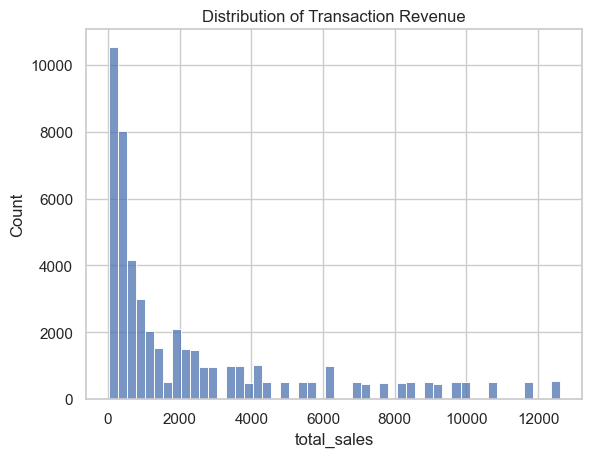

In [12]:
# Revenue distribution
sns.histplot(df["total_sales"], bins=50)
plt.title("Distribution of Transaction Revenue")
plt.show()